In [17]:
import pandas as pd
import numpy as np

In [18]:
meta = pd.read_parquet(
    "../data/metadata/metadata_filtered.parquet"
)

print(meta.shape)

meta.head()

(63001, 9)


,asin,salesRank,imUrl,categories,title,description,price,related,brand
0,0528881469,None,http://ecx.images-amazon.com/images/I/51FnRkJq...,"[[Electronics, GPS & Navigation, Vehicle GPS, ...",Rand McNally 528881469 7-inch Intelliroute TND...,"Like its award-winning predecessor, the Intell...",299.99,"{'also_viewed': ['B006ZOI9OY', 'B00C7FKT2A', '...",None
1,0594451647,None,http://ecx.images-amazon.com/images/I/51RjSETO...,"[[Electronics, Computers & Accessories, Touch ...",Barnes &amp; Noble HDTV Adapter Kit for NOOK H...,HDTV Adapter Kit for NOOK HD and NOOK HD+\nThi...,49.95,"{'also_viewed': None, 'buy_after_viewing': ['0...",None
2,0594481813,None,http://ecx.images-amazon.com/images/I/41K7ymN5...,"[[Electronics, eBook Readers & Accessories, Po...",Barnes &amp; Noble OV/HB-ADP Universal Power Kit,Power up your device with this Barnes &amp; No...,19.65,"{'also_viewed': None, 'buy_after_viewing': ['0...",Barnes &amp; Noble
3,0972683275,"{'Books': None, 'Movies & TV': None, 'Clothing...",http://ecx.images-amazon.com/images/I/41hYJ9Mw...,"[[Electronics, Accessories & Supplies, Audio &...",VideoSecu 24&quot; Long Arm TV Wall Mount Low ...,The VideoSecu TV mount is a mounting solution ...,29.99,"{'also_viewed': None, 'buy_after_viewing': ['B...",VideoSecu
4,1400532620,"{'Books': None, 'Movies & TV': None, 'Clothing...",http://ecx.images-amazon.com/images/I/519ca3cu...,"[[Electronics, eBook Readers & Accessories]]",Barnes &amp; Noble Nook eReader - no 3G,Barnes & Noble Nook eReader - no 3GMeet nook. ...,74.95,"{'also_viewed': None, 'buy_after_viewing': ['1...",Barnes &amp; Noble


In [19]:
meta.columns.tolist()

['asin',
 'salesRank',
 'imUrl',
 'categories',
 'title',
 'description',
 'price',
 'related',
 'brand']

In [20]:
meta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63001 entries, 0 to 63000
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   asin         63001 non-null  object 
 1   salesRank    21293 non-null  object 
 2   imUrl        62957 non-null  object 
 3   categories   63001 non-null  object 
 4   title        61820 non-null  object 
 5   description  61286 non-null  object 
 6   price        58969 non-null  float64
 7   related      60682 non-null  object 
 8   brand        29751 non-null  object 
dtypes: float64(1), object(8)
memory usage: 4.3+ MB


In [21]:
meta.isnull().sum().sort_values(
    ascending=False
)

salesRank      41708
brand          33250
price           4032
related         2319
description     1715
title           1181
imUrl             44
asin               0
categories         0
dtype: int64

In [22]:
meta["asin"].nunique()


63001

In [23]:
meta["asin"].duplicated().sum()


0

In [24]:
sample_cols = [
    c for c in [
        "asin",
        "title",
        "brand",
        "categories",
        "description",
        "feature"
    ]
    if c in meta.columns
]

meta[sample_cols].sample(
    5,
    random_state=42
)

,asin,title,brand,categories,description
51834,B008OPT8WO,"12 cell, 8800mAh Extended Hight Capacity Lapto...",Tech Rover,"[[Electronics, Computers & Accessories, Laptop...",If you are looking for battery for your HP COM...
4148,B000234498,C2G / Cables to Go - 27028 - Firewire 6-Pin Fe...,C2G,"[[Electronics, Computers & Accessories, Cables...",This Firewire Adapter from Cables To Go provid...
48192,B007M5NKRQ,"6 Pair - 12 Pcs - Size Medium, of Memory Foam ...",None,"[[Electronics, Accessories & Supplies, Audio &...",&#x2022;\nHere is a list of the compatible mod...
31741,B003W21IJU,Replacement HP Compaq 484170-001 Laptop Battery,CBD&amp;reg;,"[[Electronics, Computers & Accessories, Laptop...",Compatible Models:Compaq PresarioG50 / G60 / G...
41565,B005DLDO4U,Apple Wireless Keyboard MC184LL/B,Apple,"[[Electronics, Computers & Accessories, Cables...",


In [25]:
coverage = pd.DataFrame({
    "Column": meta.columns,
    "Missing %": (
        meta.isnull()
            .mean()
            .values
            * 100
    )
})

coverage.sort_values(
    "Missing %",
    ascending=False
)

,Column,Missing %
1,salesRank,66.202124
8,brand,52.776940
6,price,6.399898
7,related,3.680894
5,description,2.722179
4,title,1.874573
2,imUrl,0.069840
0,asin,0.000000
3,categories,0.000000


In [26]:
for col in meta.columns:
    print("\n")
    print(col)
    print(type(meta[col].iloc[0]))



asin
<class 'str'>


salesRank
<class 'NoneType'>


imUrl
<class 'str'>


categories
<class 'numpy.ndarray'>


title
<class 'str'>


description
<class 'str'>


price
<class 'numpy.float64'>


related
<class 'dict'>


brand
<class 'NoneType'>


In [27]:
meta.isnull().mean().sort_values(
    ascending=False
) * 100

salesRank      66.202124
brand          52.776940
price           6.399898
related         3.680894
description     2.722179
title           1.874573
imUrl           0.069840
asin            0.000000
categories      0.000000
dtype: float64

In [28]:
meta["categories"].iloc[0]

array([array(['Electronics', 'GPS & Navigation', 'Vehicle GPS', 'Trucking GPS'],
             dtype=object)                                                      ],
      dtype=object)

In [29]:
meta["categories"].sample(
    5,
    random_state=42
).tolist()

[array([array(['Electronics', 'Computers & Accessories',
               'Laptop & Netbook Computer Accessories', 'Batteries'], dtype=object)],
       dtype=object),
 array([array(['Electronics', 'Computers & Accessories', 'Cables & Accessories',
               'Cables & Interconnects'], dtype=object)                         ],
       dtype=object),
 array([array(['Electronics', 'Accessories & Supplies',
               'Audio & Video Accessories', 'Headphone Accessories', 'Earpads'],
              dtype=object)                                                     ],
       dtype=object),
 array([array(['Electronics', 'Computers & Accessories',
               'Laptop & Netbook Computer Accessories', 'Batteries'], dtype=object)],
       dtype=object),
 array([array(['Electronics', 'Computers & Accessories', 'Cables & Accessories',
               'Keyboards'], dtype=object)                                      ],
       dtype=object)]

In [30]:
meta_clean = meta.copy()

In [31]:
meta_clean["title"] = (
    meta_clean["title"]
    .fillna("")
)

meta_clean["description"] = (
    meta_clean["description"]
    .fillna("")
)

meta_clean["brand"] = (
    meta_clean["brand"]
    .fillna("")
)

In [32]:
def flatten_categories(x):

    try:
        return " ".join(
            [
                str(item)
                for sublist in x
                for item in sublist
            ]
        )

    except:
        return ""

In [37]:
meta_clean["category_text"] = (
    meta_clean["categories"]
    .apply(flatten_categories)
)

meta_clean[
    [
        "asin",
        "category_text"
    ]
].head()

,asin,category_text
0,0528881469,Electronics GPS & Navigation Vehicle GPS Truck...
1,0594451647,Electronics Computers & Accessories Touch Scre...
2,0594481813,Electronics eBook Readers & Accessories Power ...
3,0972683275,Electronics Accessories & Supplies Audio & Vid...
4,1400532620,Electronics eBook Readers & Accessories


In [38]:
meta_clean["product_text"] = (
    meta_clean["title"]
    + " "
    + meta_clean["brand"]
    + " "
    + meta_clean["category_text"]
    + " "
    + meta_clean["description"]
)


meta_clean[
    [
        "asin",
        "product_text"
    ]
].sample(
    5,
    random_state=42
)

,asin,product_text
51834,B008OPT8WO,"12 cell, 8800mAh Extended Hight Capacity Lapto..."
4148,B000234498,C2G / Cables to Go - 27028 - Firewire 6-Pin Fe...
48192,B007M5NKRQ,"6 Pair - 12 Pcs - Size Medium, of Memory Foam ..."
31741,B003W21IJU,Replacement HP Compaq 484170-001 Laptop Batter...
41565,B005DLDO4U,Apple Wireless Keyboard MC184LL/B Apple Electr...


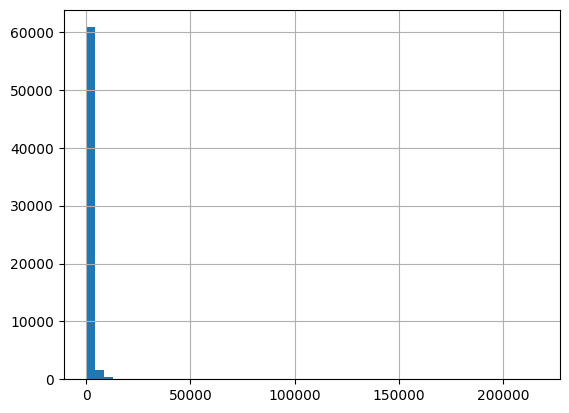

In [39]:
meta_clean["text_length"] = (
    meta_clean["product_text"]
    .str.len()
)

meta_clean["text_length"].hist(
    bins=50
)

catalog = meta_clean[
    [
        "asin",
        "title",
        "brand",
        "category_text",
        "description",
        "product_text"
    ]
]

In [40]:
catalog.to_parquet(
    "../data/catalog.parquet",
    index=False
)

print(
    "Saved catalog.parquet"
)

Saved catalog.parquet


In [41]:
print(catalog.shape)
print(catalog["product_text"].str.len().describe())

(63001, 6)
count     63001.000000
mean       1071.903367
std        2257.186542
min          37.000000
25%         247.000000
50%         592.000000
75%        1200.000000
max      216269.000000
Name: product_text, dtype: float64
